# AAI 511 Final Team Project: Data Engineering and Preprocessing

This notebook prepares the MIDI composer dataset for the LSTM and CNN model notebooks. It filters the dataset to the four required composers, checks file quality, extracts MIDI features, creates visualizations, and saves model-ready files for the team.

## 1. Install Libraries

These libraries are used to read MIDI files, create piano-roll matrices, split the data, and build charts.

In [1]:
!pip install music21 pretty_midi matplotlib pandas numpy scikit-learn tqdm -q

## 2. Imports and Settings

All main settings are kept in one place so the team can adjust them later if needed.

In [2]:
import os
import json
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from music21 import converter, note, chord, tempo
import pretty_midi

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

TARGET_COMPOSERS = ['Bach', 'Beethoven', 'Chopin', 'Mozart']

# LSTM settings
SEQUENCE_LENGTH = 100
LSTM_STEP = 10

# CNN piano-roll settings
PIANO_ROLL_FS = 10
PIANO_ROLL_FRAMES = 128

# Split settings
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_STATE = 42

print('Settings loaded.')
print('Target composers:', TARGET_COMPOSERS)
print(f'LSTM window: {SEQUENCE_LENGTH} events, step {LSTM_STEP}')
print(f'CNN piano-roll shape: 128 x {PIANO_ROLL_FRAMES}')

Settings loaded.
Target composers: ['Bach', 'Beethoven', 'Chopin', 'Mozart']
LSTM window: 100 events, step 10
CNN piano-roll shape: 128 x 128


## 3. Connect to Google Drive and Find the Dataset

This notebook is set up to work for Ahmed and the team.

Put the unzipped dataset in one of these locations in **My Drive**:

`AAI511_TM1/midi_dataset` or `AAI-511-Group 4/midi_dataset`

Inside `midi_dataset`, there should be four folders: `Bach`, `Beethoven`, `Chopin`, and `Mozart`. The notebook will check the folders and then save the processed files into a `processed_data` folder next to the dataset.

In [3]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

# This cell is team-friendly. It checks the common project folders first,
# then searches My Drive for a folder named midi_dataset.
MY_DRIVE_ROOT = '/content/drive/MyDrive'
PROJECT_FOLDER_CANDIDATES = [
    'AAI511_TM1',        # simple personal/team folder option
    'AAI-511-Group 4'   # shared folder shortcut option
]

REQUIRED_COMPOSER_FOLDERS = TARGET_COMPOSERS


def is_valid_dataset_folder(path):
    """Return True only if the path has all four required composer folders."""
    if not os.path.isdir(path):
        return False
    return all(os.path.isdir(os.path.join(path, composer)) for composer in REQUIRED_COMPOSER_FOLDERS)


def find_dataset_folder():
    """Find midi_dataset in the expected project folders or by searching My Drive."""
    checked_paths = []

    # First check the expected folder names.
    for folder_name in PROJECT_FOLDER_CANDIDATES:
        candidate = os.path.join(MY_DRIVE_ROOT, folder_name, 'midi_dataset')
        checked_paths.append(candidate)
        if is_valid_dataset_folder(candidate):
            return candidate, checked_paths

    # Backup search. This helps if a teammate names the project folder differently.
    print('Expected folders not found. Searching My Drive for midi_dataset...')
    skip_dirs = {'processed_data', '__MACOSX', '.ipynb_checkpoints'}

    for root, dirs, files in os.walk(MY_DRIVE_ROOT):
        # Keep the search cleaner and avoid output/system folders.
        dirs[:] = [d for d in dirs if d not in skip_dirs and not d.startswith('._')]

        if os.path.basename(root) == 'midi_dataset' and is_valid_dataset_folder(root):
            return root, checked_paths

    return None, checked_paths


DATA_ROOT, checked_paths = find_dataset_folder()

if DATA_ROOT is None:
    print('\nChecked these expected paths:')
    for p in checked_paths:
        print('-', p)

    print('\nFolders currently visible in My Drive:')
    print(os.listdir(MY_DRIVE_ROOT)[:50])

    raise FileNotFoundError(
        'Could not find a valid midi_dataset folder.\n\n'
        'Use this structure in Google Drive:\n'
        'My Drive/AAI511_TM1/midi_dataset/Bach\n'
        'My Drive/AAI511_TM1/midi_dataset/Beethoven\n'
        'My Drive/AAI511_TM1/midi_dataset/Chopin\n'
        'My Drive/AAI511_TM1/midi_dataset/Mozart\n\n'
        'Or use the shared folder shortcut:\n'
        'My Drive/AAI-511-Group 4/midi_dataset/Bach, Beethoven, Chopin, Mozart'
    )

BASE_DIR = os.path.dirname(DATA_ROOT)
OUTPUT_DIR = os.path.join(BASE_DIR, 'processed_data')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Project folder:', BASE_DIR)
print('Dataset folder:', DATA_ROOT)
print('Output folder :', OUTPUT_DIR)
print('\nDataset folder contents:')
print(os.listdir(DATA_ROOT))


Mounted at /content/drive
Project folder: /content/drive/MyDrive/AAI511_TM1
Dataset folder: /content/drive/MyDrive/AAI511_TM1/midi_dataset
Output folder : /content/drive/MyDrive/AAI511_TM1/processed_data

Dataset folder contents:
['Bach', 'Beethoven', 'Mozart', 'Chopin']


## 4. Dataset Exploration

This section scans the four composer folders and counts MIDI files. The search is recursive, so it also finds MIDI files inside nested folders.

In [4]:
def collect_midi_files(data_root, composers):
    records = []

    for composer in composers:
        composer_path = os.path.join(data_root, composer)

        if not os.path.exists(composer_path):
            print(f'Warning: folder not found for {composer}')
            continue

        for root, dirs, files in os.walk(composer_path):
            # Ignore Mac metadata folders if they appear
            dirs[:] = [d for d in dirs if d != '__MACOSX' and not d.startswith('._')]

            for filename in files:
                lower_name = filename.lower()
                if lower_name.startswith('._') or lower_name == '.ds_store':
                    continue

                if lower_name.endswith(('.mid', '.midi')):
                    records.append({
                        'filepath': os.path.join(root, filename),
                        'filename': filename,
                        'composer': composer
                    })

    return pd.DataFrame(records)


df_files = collect_midi_files(DATA_ROOT, TARGET_COMPOSERS)

if df_files.empty:
    raise ValueError('No MIDI files were found. Check DATA_ROOT and folder names.')

display(df_files.head())

summary_counts = (
    df_files.groupby('composer')
    .size()
    .reindex(TARGET_COMPOSERS, fill_value=0)
    .reset_index(name='total_midi_files')
)

display(summary_counts)
print(f'Total MIDI files found: {len(df_files)}')

,filepath,filename,composer
0,/content/drive/MyDrive/AAI511_TM1/midi_dataset...,Bwv0556 Short Prelude and Fugue n4 (Spurious).mid,Bach
1,/content/drive/MyDrive/AAI511_TM1/midi_dataset...,Bwv1005 Violin Sonata n3 1mov Adagio.mid,Bach
2,/content/drive/MyDrive/AAI511_TM1/midi_dataset...,Bwv0549 Prelude and Fugue.mid,Bach
3,/content/drive/MyDrive/AAI511_TM1/midi_dataset...,Bwv0558 Short Prelude and Fugue n6 (Spurious).mid,Bach
4,/content/drive/MyDrive/AAI511_TM1/midi_dataset...,Bwv0817 French Suite n6.mid,Bach


,composer,total_midi_files
0,Bach,1024
1,Beethoven,213
2,Chopin,136
3,Mozart,257


Total MIDI files found: 1630


## 4.1 Composer Distribution Chart

This chart helps show whether the dataset is balanced across the four composers.

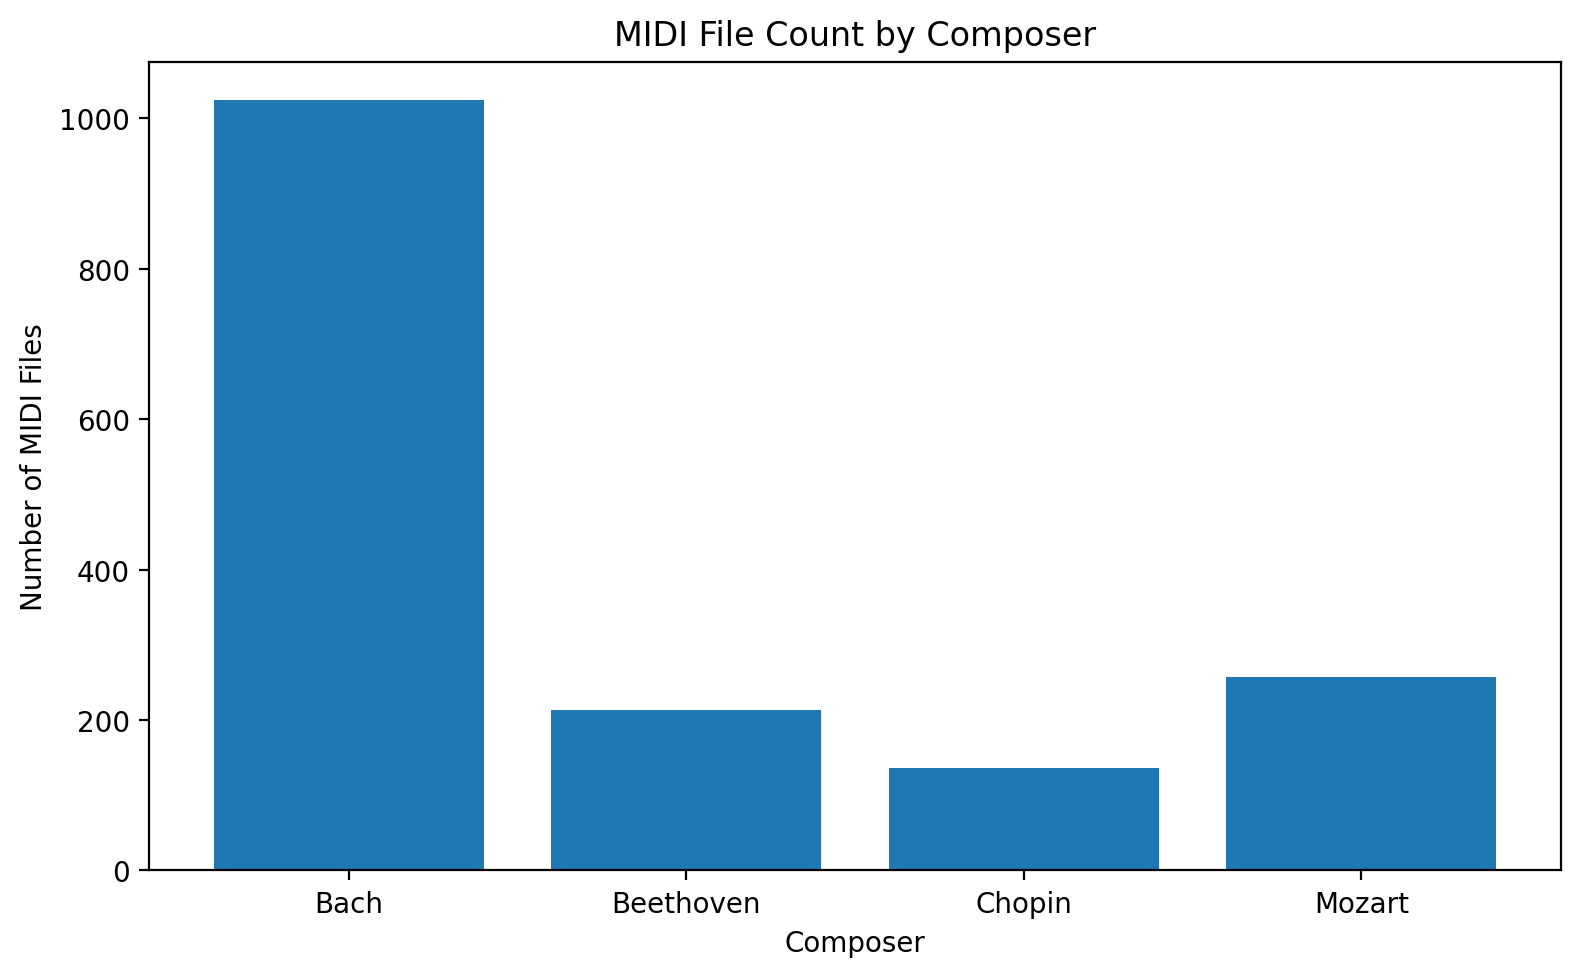

In [5]:
plt.figure(figsize=(8, 5))
plt.bar(summary_counts['composer'], summary_counts['total_midi_files'])
plt.title('MIDI File Count by Composer')
plt.xlabel('Composer')
plt.ylabel('Number of MIDI Files')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'composer_distribution.png'), dpi=150)
plt.show()

## 5. Data Cleaning

This step checks whether each MIDI file can be opened and whether it contains notes or chords. Files that cannot be parsed are removed from the clean file list.

In [6]:
def is_valid_midi(filepath):
    try:
        stream = converter.parse(filepath)
        elements = stream.recurse().notes
        note_count = sum(1 for el in elements if isinstance(el, (note.Note, chord.Chord)))
        return note_count > 0
    except Exception:
        return False


print('Checking MIDI files. This may take several minutes...')
valid_flags = []

for fp in tqdm(df_files['filepath'], desc='Validating MIDI files'):
    valid_flags.append(is_valid_midi(fp))

df_files['valid'] = valid_flags
df_clean = df_files[df_files['valid']].reset_index(drop=True)

clean_summary = (
    df_files.groupby('composer')
    .agg(total_files=('filepath', 'count'), valid_files=('valid', 'sum'))
    .reindex(TARGET_COMPOSERS)
    .reset_index()
)
clean_summary['removed_files'] = clean_summary['total_files'] - clean_summary['valid_files']

display(clean_summary)

if df_clean.empty:
    raise ValueError('No valid MIDI files remained after cleaning.')

Checking MIDI files. This may take several minutes...


Validating MIDI files: 100%|██████████| 1630/1630 [22:20<00:00,  1.22it/s]


,composer,total_files,valid_files,removed_files
0,Bach,1024,1024,0
1,Beethoven,213,213,0
2,Chopin,136,136,0
3,Mozart,257,257,0


## 6. Train, Validation, and Test Split

The split is done at the **file level** before creating LSTM windows. This avoids data leakage, so parts of the same MIDI file do not appear in both training and testing.

In [7]:
def stratified_file_split(df, train=0.70, val=0.15, seed=42):
    test = 1.0 - train - val

    df_train, df_temp = train_test_split(
        df,
        test_size=(val + test),
        stratify=df['composer'],
        random_state=seed
    )

    relative_test = test / (val + test)

    df_val, df_test = train_test_split(
        df_temp,
        test_size=relative_test,
        stratify=df_temp['composer'],
        random_state=seed
    )

    return (
        df_train.reset_index(drop=True),
        df_val.reset_index(drop=True),
        df_test.reset_index(drop=True)
    )


df_train, df_val, df_test = stratified_file_split(
    df_clean,
    train=TRAIN_RATIO,
    val=VAL_RATIO,
    seed=RANDOM_STATE
)

df_train['split'] = 'train'
df_val['split'] = 'val'
df_test['split'] = 'test'

df_splits = pd.concat([df_train, df_val, df_test], ignore_index=True)
df_splits.to_csv(os.path.join(OUTPUT_DIR, 'file_level_splits.csv'), index=False)

split_table = (
    df_splits.groupby(['split', 'composer'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=['train', 'val', 'test'])
    .reindex(columns=TARGET_COMPOSERS)
)

display(split_table)
print('File-level split saved.')

composer,Bach,Beethoven,Chopin,Mozart
split,,,,
train,716,149,95,180
val,153,32,21,38
test,155,32,20,39


File-level split saved.


## 7. Feature Extraction Functions

The LSTM model needs note and chord sequences. The CNN model needs piano-roll matrices. This section creates both formats from each MIDI file.

In [8]:
def extract_note_features(filepath):
    try:
        stream = converter.parse(filepath)
        elements = stream.recurse().notes

        sequence = []
        pitches = []
        total_duration = 0.0

        for el in elements:
            if isinstance(el, note.Note):
                sequence.append(str(el.pitch))
                pitches.append(int(el.pitch.midi))
                total_duration += float(el.duration.quarterLength)

            elif isinstance(el, chord.Chord):
                chord_pitches = sorted([int(p.midi) for p in el.pitches])
                chord_token = '.'.join(str(p) for p in chord_pitches)
                sequence.append(chord_token)
                pitches.extend(chord_pitches)
                total_duration += float(el.duration.quarterLength)

        tempo_marks = stream.flatten().getElementsByClass(tempo.MetronomeMark)
        bpm_values = [tm.number for tm in tempo_marks if tm.number is not None]
        bpm = float(bpm_values[0]) if bpm_values else 120.0

        mean_pitch = float(np.mean(pitches)) if pitches else np.nan
        mean_pitch_norm = mean_pitch / 127.0 if pitches else np.nan

        return {
            'sequence': sequence,
            'pitches': pitches,
            'tempo_bpm': bpm,
            'duration_ql': total_duration,
            'sequence_length': len(sequence),
            'mean_pitch': mean_pitch,
            'mean_pitch_norm': mean_pitch_norm
        }

    except Exception:
        return None


def extract_piano_roll(filepath, fs=PIANO_ROLL_FS, max_frames=PIANO_ROLL_FRAMES):
    try:
        pm = pretty_midi.PrettyMIDI(filepath)
        roll = pm.get_piano_roll(fs=fs)

        # Normalize to binary note activity. This gives the CNN a clean 0/1 input matrix.
        roll = (roll > 0).astype(np.float32)

        if roll.shape[1] >= max_frames:
            return roll[:, :max_frames]

        pad = np.zeros((128, max_frames - roll.shape[1]), dtype=np.float32)
        return np.concatenate([roll, pad], axis=1)

    except Exception:
        return None


print('Feature extraction functions ready.')

Feature extraction functions ready.


## 8. Extract Features by Split

This section creates one feature record per MIDI file. If a file fails during feature extraction, it is skipped and counted.

In [9]:
def process_split(df_split, split_name):
    records = []
    skipped = 0

    print(f'Processing {split_name} split...')

    for _, row in tqdm(df_split.iterrows(), total=len(df_split), desc=split_name):
        note_features = extract_note_features(row['filepath'])
        piano_roll = extract_piano_roll(row['filepath'])

        if note_features is None or piano_roll is None or len(note_features['sequence']) == 0:
            skipped += 1
            continue

        records.append({
            'filepath': row['filepath'],
            'filename': row['filename'],
            'composer': row['composer'],
            'split': split_name,
            'sequence': note_features['sequence'],
            'pitches': note_features['pitches'],
            'piano_roll': piano_roll,
            'tempo_bpm': note_features['tempo_bpm'],
            'duration_ql': note_features['duration_ql'],
            'sequence_length': note_features['sequence_length'],
            'mean_pitch': note_features['mean_pitch'],
            'mean_pitch_norm': note_features['mean_pitch_norm']
        })

    print(f'{split_name}: {len(records)} processed, {skipped} skipped')
    return records


train_records = process_split(df_train, 'train')
val_records = process_split(df_val, 'val')
test_records = process_split(df_test, 'test')

all_records = train_records + val_records + test_records

if len(all_records) == 0:
    raise ValueError('No feature records were created.')

feature_summary = pd.DataFrame([
    {
        'filepath': r['filepath'],
        'filename': r['filename'],
        'composer': r['composer'],
        'split': r['split'],
        'sequence_length': r['sequence_length'],
        'tempo_bpm': r['tempo_bpm'],
        'duration_ql': r['duration_ql'],
        'mean_pitch': r['mean_pitch'],
        'mean_pitch_norm': r['mean_pitch_norm']
    }
    for r in all_records
])

feature_summary.to_csv(os.path.join(OUTPUT_DIR, 'feature_summary.csv'), index=False)

display(feature_summary.head())
print(f'Total feature records: {len(feature_summary)}')

Processing train split...


train: 100%|██████████| 1140/1140 [23:03<00:00,  1.21s/it]


train: 1139 processed, 1 skipped
Processing val split...


val: 100%|██████████| 244/244 [04:36<00:00,  1.13s/it]


val: 243 processed, 1 skipped
Processing test split...


test: 100%|██████████| 246/246 [06:07<00:00,  1.49s/it]

test: 246 processed, 0 skipped


,filepath,filename,composer,split,sequence_length,tempo_bpm,duration_ql,mean_pitch,mean_pitch_norm
0,/content/drive/MyDrive/AAI511_TM1/midi_dataset...,Bwv032.6.mid,Bach,train,283,96.00,272.000000,59.855124,0.471300
1,/content/drive/MyDrive/AAI511_TM1/midi_dataset...,017206b_.mid,Bach,train,492,88.00,400.750000,63.941057,0.503473
2,/content/drive/MyDrive/AAI511_TM1/midi_dataset...,Prelude n22 op28 ''Impatience''.mid,Chopin,train,371,178.31,272.166667,57.736926,0.454621
3,/content/drive/MyDrive/AAI511_TM1/midi_dataset...,01. Kyrie Eleison .mid,Bach,train,8579,96.00,5082.500000,63.452067,0.499623
4,/content/drive/MyDrive/AAI511_TM1/midi_dataset...,Prelude and Fugue in C Sharp BWV 872.mid,Bach,train,1853,120.00,878.250000,61.562273,0.484742


Total feature records: 1628


## 9. Sequence Length and Tempo Summary

These statistics help explain the dataset in the final report.

Sequence length summary by composer:


,count,mean,std,min,25%,50%,75%,max
composer,,,,,,,,
Bach,1024.0,1507.51,2721.27,86.0,282.00,590.5,1398.75,31443.0
Beethoven,212.0,5949.06,6670.05,82.0,1102.75,3644.5,7847.75,41041.0
Chopin,136.0,1527.49,2076.05,88.0,624.25,1017.0,1581.00,17270.0
Mozart,256.0,4527.54,3553.68,100.0,1726.75,3605.0,6613.75,15520.0


Tempo summary by composer:


,count,mean,std,min,25%,50%,75%,max
composer,,,,,,,,
Bach,1024.0,95.62,28.33,25.0,84.0,96.0,100.00,250.0
Beethoven,212.0,129.44,64.93,20.0,100.0,118.5,149.25,460.0
Chopin,136.0,125.54,44.39,35.0,100.0,120.0,150.00,268.0
Mozart,256.0,114.47,46.02,35.0,80.0,120.0,132.00,275.0


<Figure size 900x500 with 0 Axes>

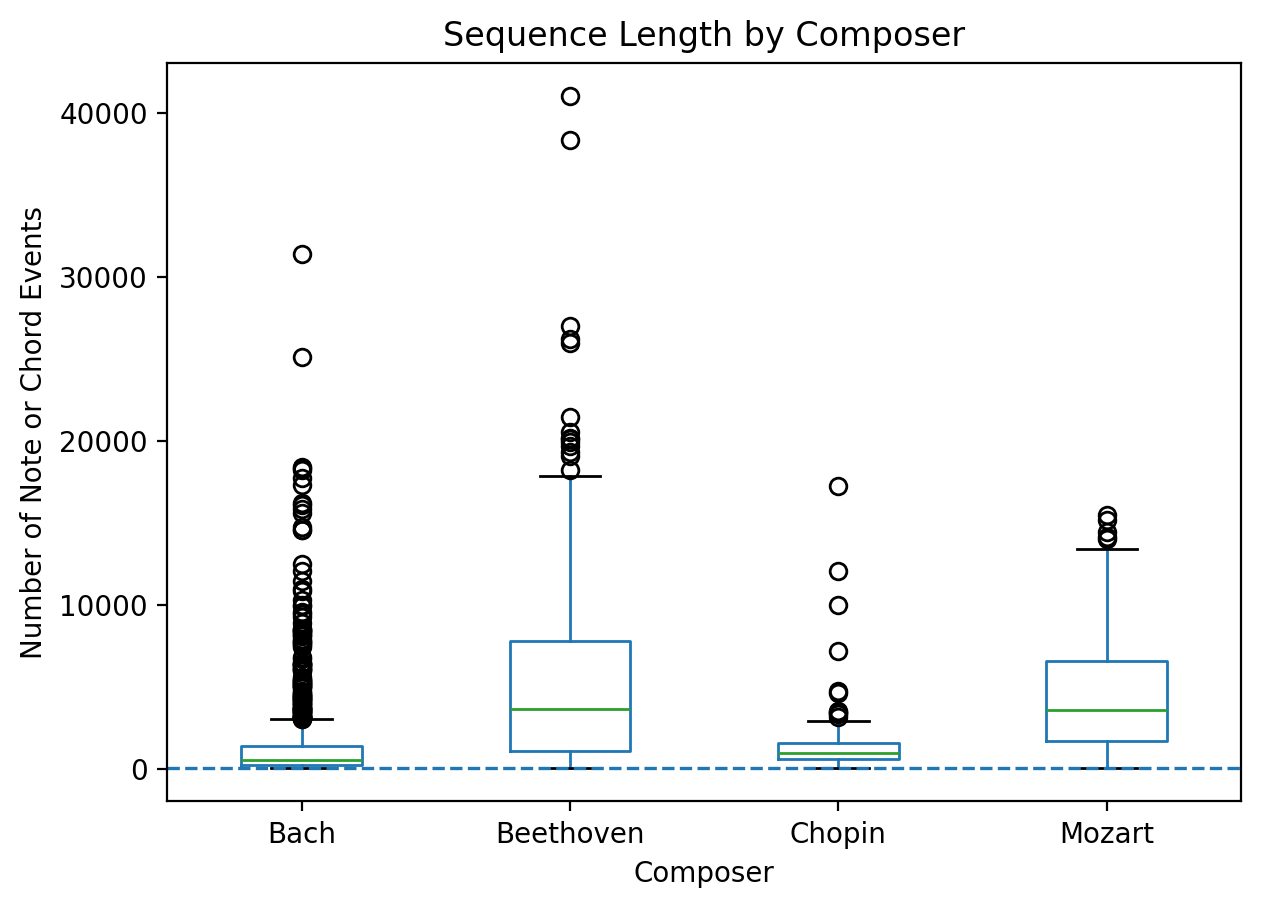

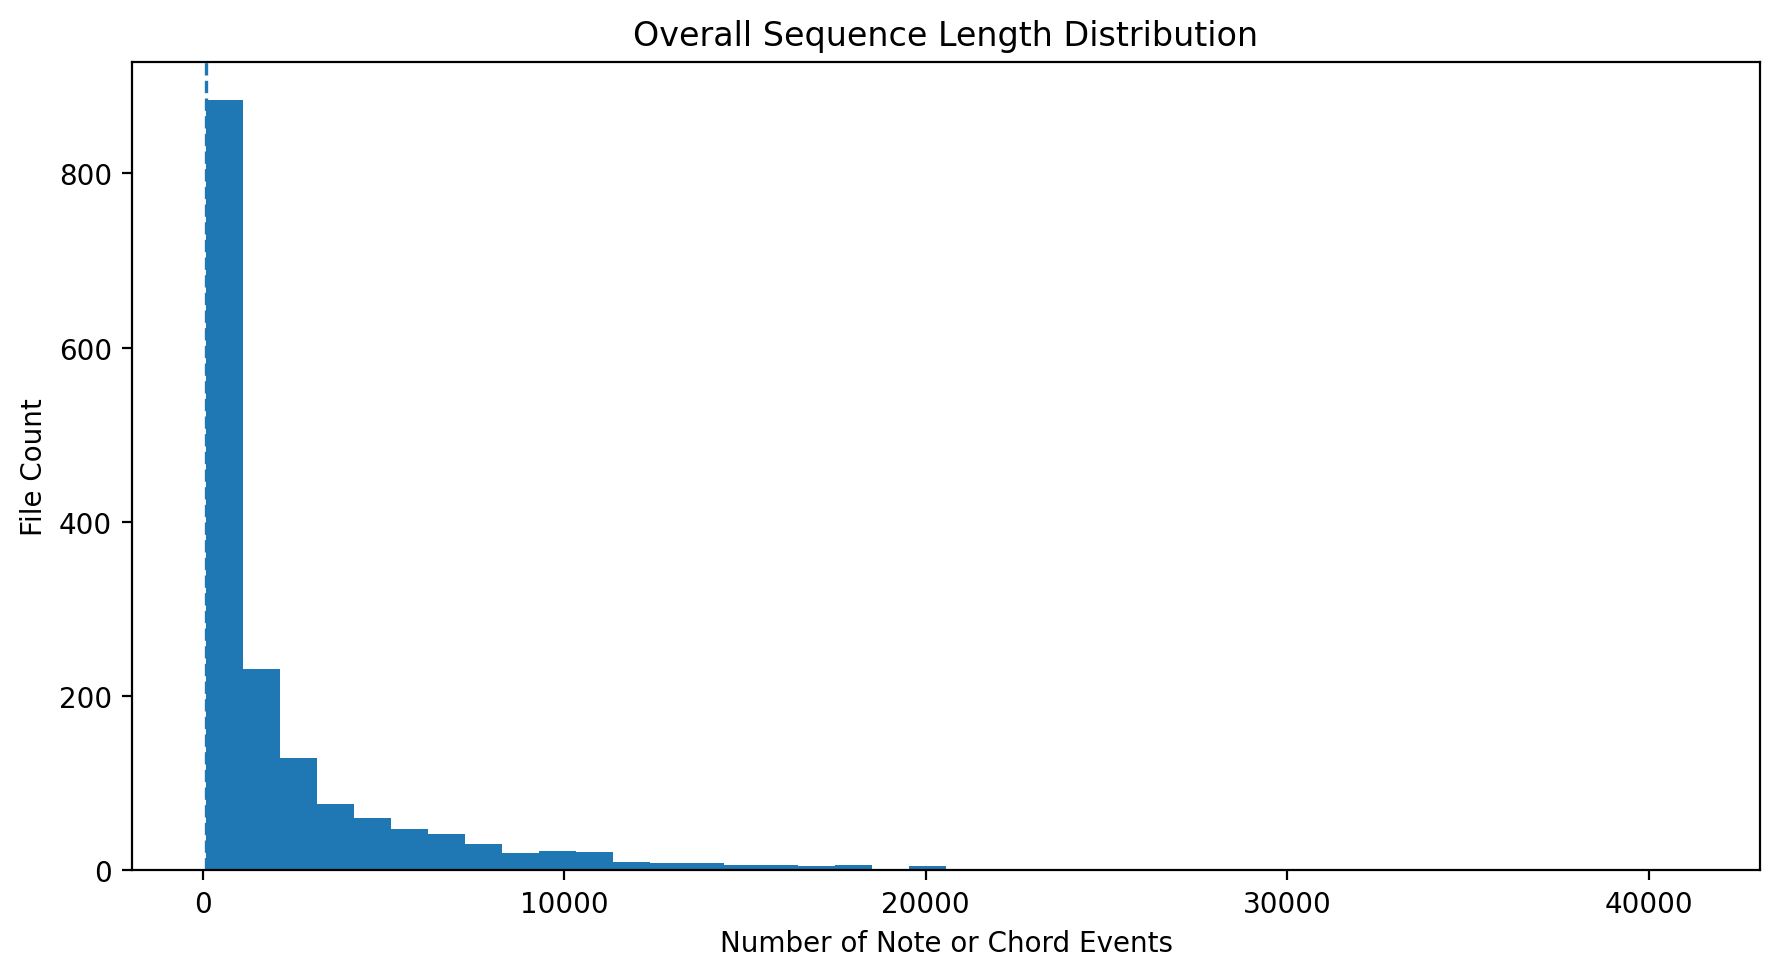

In [10]:
print('Sequence length summary by composer:')
display(feature_summary.groupby('composer')['sequence_length'].describe().round(2))

print('Tempo summary by composer:')
display(feature_summary.groupby('composer')['tempo_bpm'].describe().round(2))

plt.figure(figsize=(9, 5))
feature_summary.boxplot(column='sequence_length', by='composer', grid=False)
plt.axhline(SEQUENCE_LENGTH, linestyle='--', linewidth=1.2)
plt.title('Sequence Length by Composer')
plt.suptitle('')
plt.xlabel('Composer')
plt.ylabel('Number of Note or Chord Events')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sequence_length_by_composer.png'), dpi=150)
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(feature_summary['sequence_length'], bins=40)
plt.axvline(SEQUENCE_LENGTH, linestyle='--', linewidth=1.2)
plt.title('Overall Sequence Length Distribution')
plt.xlabel('Number of Note or Chord Events')
plt.ylabel('File Count')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sequence_length_distribution.png'), dpi=150)
plt.show()

## 10. Note Frequency Visualization

This chart shows the most common individual notes for each composer. Chord tokens are excluded from this plot to keep the chart readable.

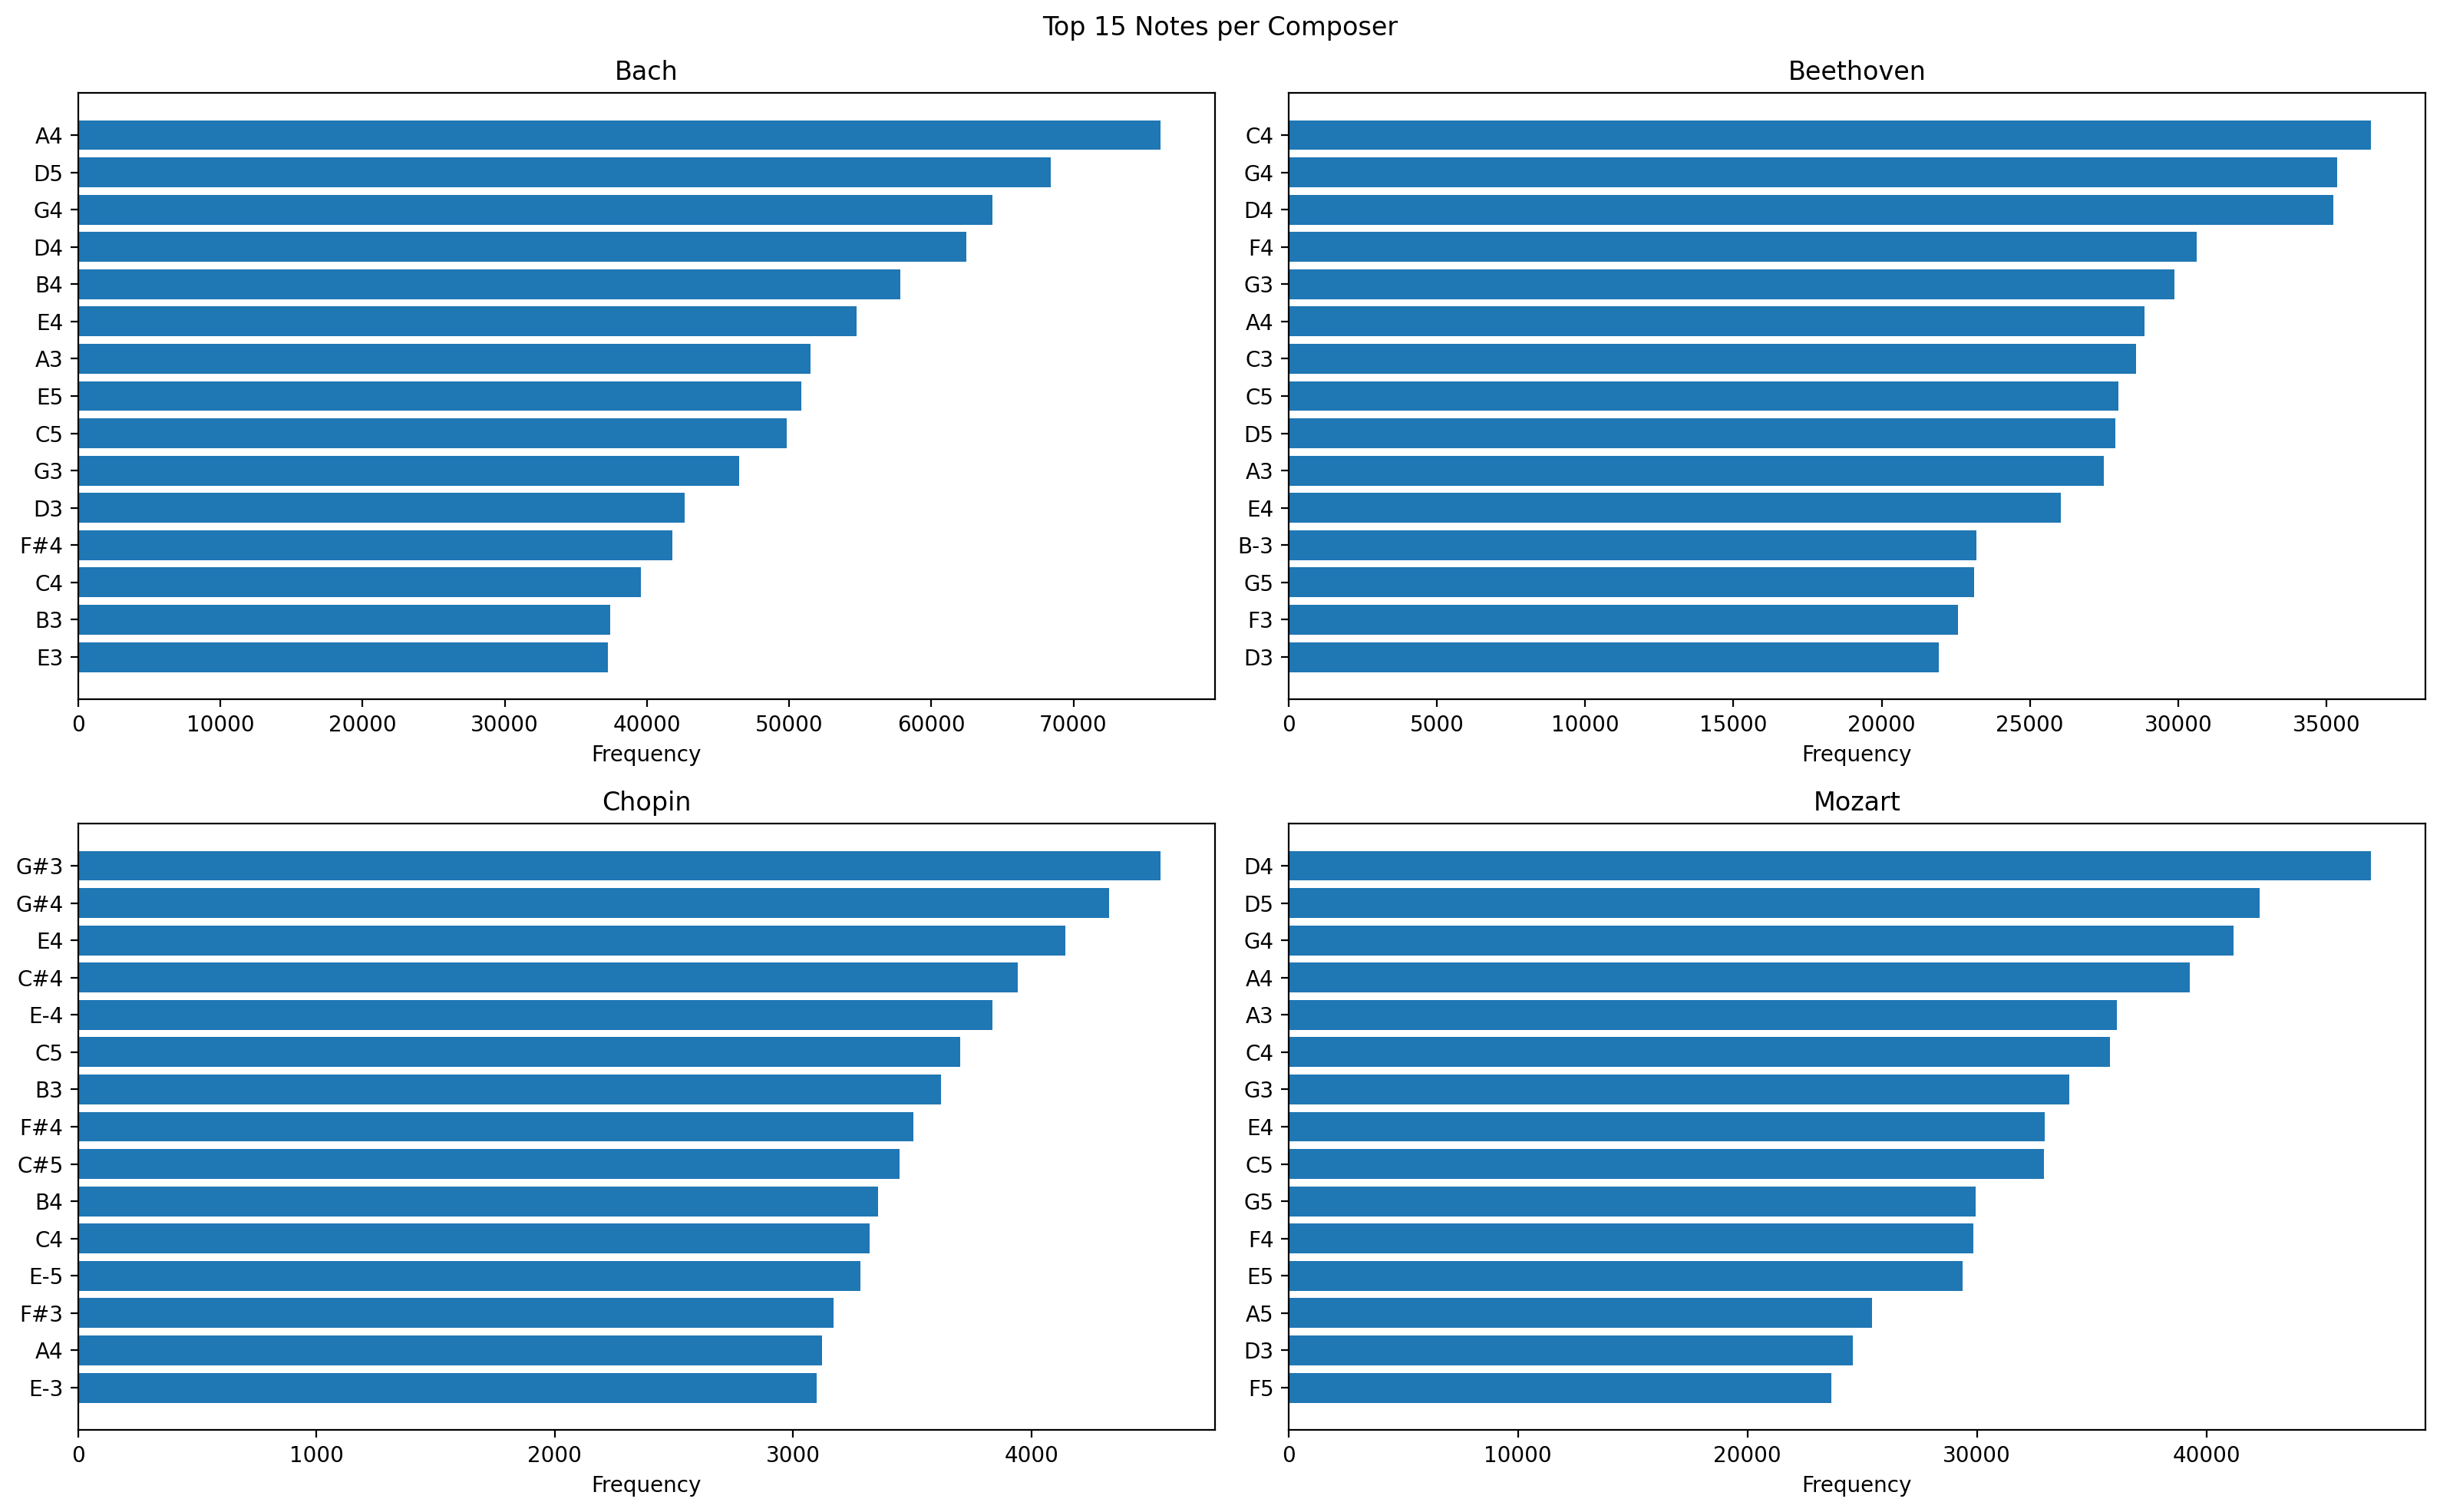

In [11]:
def get_top_notes(records, composer, n=15):
    tokens = []
    for r in records:
        if r['composer'] == composer:
            for token in r['sequence']:
                if '.' not in token:
                    tokens.append(token)
    return Counter(tokens).most_common(n)


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, composer in zip(axes.flat, TARGET_COMPOSERS):
    data = get_top_notes(all_records, composer)

    if not data:
        ax.set_title(f'{composer}: no data')
        continue

    notes, counts = zip(*data)
    ax.barh(notes[::-1], counts[::-1])
    ax.set_title(composer)
    ax.set_xlabel('Frequency')

plt.suptitle('Top 15 Notes per Composer')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'note_frequency_by_composer.png'), dpi=150)
plt.show()

## 11. Sample Piano-Roll Visualization

A piano-roll is a matrix where rows represent MIDI pitches and columns represent time frames. This is the input format prepared for the CNN model.

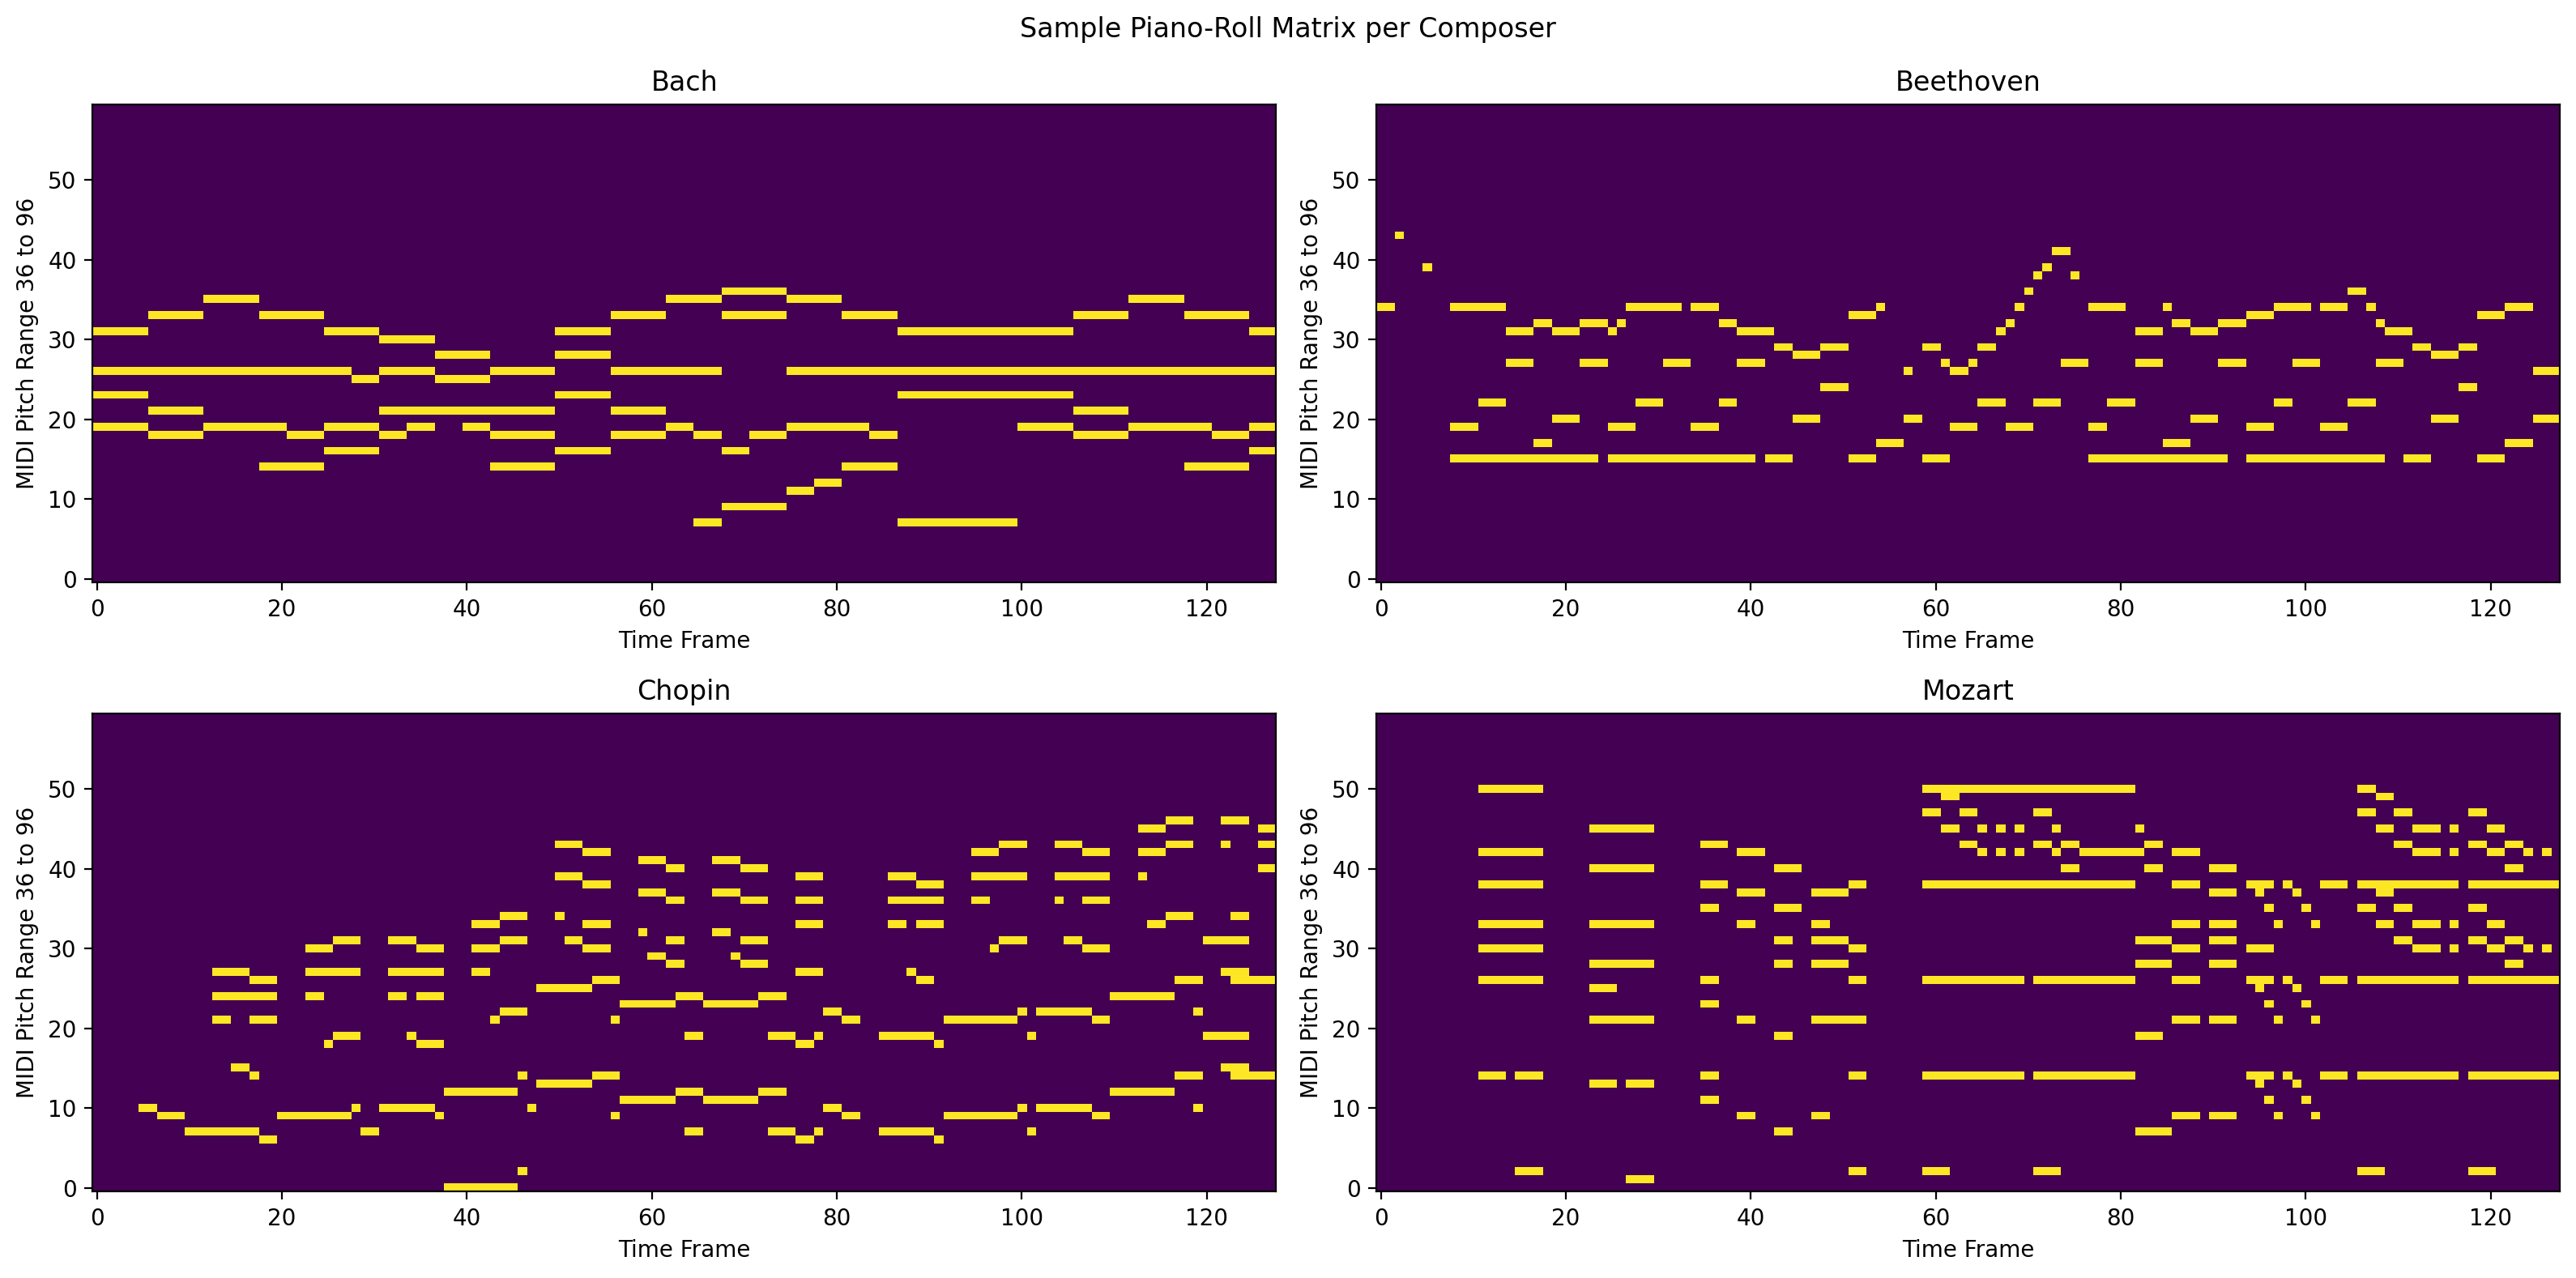

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for ax, composer in zip(axes.flat, TARGET_COMPOSERS):
    sample = next((r for r in all_records if r['composer'] == composer), None)

    if sample is None:
        ax.set_title(f'{composer}: no data')
        continue

    roll = sample['piano_roll']
    ax.imshow(roll[36:96, :], aspect='auto', origin='lower', interpolation='nearest')
    ax.set_title(composer)
    ax.set_xlabel('Time Frame')
    ax.set_ylabel('MIDI Pitch Range 36 to 96')

plt.suptitle('Sample Piano-Roll Matrix per Composer')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_piano_rolls.png'), dpi=150)
plt.show()

## 12. Build LSTM Inputs

The LSTM model uses integer-encoded note and chord sequences. The windows are created **after** the file-level split to avoid leakage between training and testing.

In [13]:
all_tokens = []
for r in train_records:
    all_tokens.extend(r['sequence'])

# Reserve 0 for unknown or padding if needed later.
vocab = sorted(set(all_tokens))
token_to_int = {token: idx + 1 for idx, token in enumerate(vocab)}

print(f'Vocabulary size from training data: {len(token_to_int)}')


def make_lstm_windows(records, token_to_int, seq_len=SEQUENCE_LENGTH, step=LSTM_STEP):
    X = []
    y = []

    for r in records:
        encoded = [token_to_int.get(token, 0) for token in r['sequence']]

        if len(encoded) < seq_len:
            continue

        for start in range(0, len(encoded) - seq_len + 1, step):
            X.append(encoded[start:start + seq_len])
            y.append(r['composer'])

    if len(X) == 0:
        return np.empty((0, seq_len), dtype=np.int32), np.array([], dtype=object)

    return np.array(X, dtype=np.int32), np.array(y)


X_seq_train, y_seq_train_labels = make_lstm_windows(train_records, token_to_int)
X_seq_val, y_seq_val_labels = make_lstm_windows(val_records, token_to_int)
X_seq_test, y_seq_test_labels = make_lstm_windows(test_records, token_to_int)

print('LSTM shapes:')
print('Train:', X_seq_train.shape, Counter(y_seq_train_labels))
print('Val  :', X_seq_val.shape, Counter(y_seq_val_labels))
print('Test :', X_seq_test.shape, Counter(y_seq_test_labels))

if X_seq_train.shape[0] == 0:
    raise ValueError('No LSTM training windows were created. Try reducing SEQUENCE_LENGTH.')

Vocabulary size from training data: 23612
LSTM shapes:
Train: (279349, 100) Counter({np.str_('Bach'): 99310, np.str_('Mozart'): 83584, np.str_('Beethoven'): 82053, np.str_('Chopin'): 14402})
Val  : (53757, 100) Counter({np.str_('Beethoven'): 18829, np.str_('Mozart'): 16664, np.str_('Bach'): 15745, np.str_('Chopin'): 2519})
Test : (68694, 100) Counter({np.str_('Bach'): 29652, np.str_('Beethoven'): 23230, np.str_('Mozart'): 13245, np.str_('Chopin'): 2567})


## 13. Build CNN Inputs

The CNN model uses one piano-roll matrix per MIDI file. The values are binary, where 1 means a pitch is active at that time frame.

In [14]:
def make_cnn_arrays(records):
    X = []
    y = []

    for r in records:
        X.append(r['piano_roll'])
        y.append(r['composer'])

    X = np.stack(X, axis=0).astype(np.float32)
    X = X[:, :, :, np.newaxis]
    y = np.array(y)

    return X, y


X_cnn_train, y_cnn_train_labels = make_cnn_arrays(train_records)
X_cnn_val, y_cnn_val_labels = make_cnn_arrays(val_records)
X_cnn_test, y_cnn_test_labels = make_cnn_arrays(test_records)

print('CNN shapes:')
print('Train:', X_cnn_train.shape, Counter(y_cnn_train_labels))
print('Val  :', X_cnn_val.shape, Counter(y_cnn_val_labels))
print('Test :', X_cnn_test.shape, Counter(y_cnn_test_labels))

CNN shapes:
Train: (1139, 128, 128, 1) Counter({np.str_('Bach'): 716, np.str_('Mozart'): 179, np.str_('Beethoven'): 149, np.str_('Chopin'): 95})
Val  : (243, 128, 128, 1) Counter({np.str_('Bach'): 153, np.str_('Mozart'): 38, np.str_('Beethoven'): 31, np.str_('Chopin'): 21})
Test : (246, 128, 128, 1) Counter({np.str_('Bach'): 155, np.str_('Mozart'): 39, np.str_('Beethoven'): 32, np.str_('Chopin'): 20})


## 14. Encode Labels and Save Outputs

The labels are encoded consistently for both models:

0 = Bach  
1 = Beethoven  
2 = Chopin  
3 = Mozart

In [15]:
label_encoder = LabelEncoder()
label_encoder.fit(TARGET_COMPOSERS)

y_seq_train = label_encoder.transform(y_seq_train_labels)
y_seq_val = label_encoder.transform(y_seq_val_labels)
y_seq_test = label_encoder.transform(y_seq_test_labels)

y_cnn_train = label_encoder.transform(y_cnn_train_labels)
y_cnn_val = label_encoder.transform(y_cnn_val_labels)
y_cnn_test = label_encoder.transform(y_cnn_test_labels)

print('Label encoding:')
for composer, encoded_value in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f'{encoded_value}: {composer}')

# Save LSTM arrays
np.save(os.path.join(OUTPUT_DIR, 'X_seq_train.npy'), X_seq_train)
np.save(os.path.join(OUTPUT_DIR, 'X_seq_val.npy'), X_seq_val)
np.save(os.path.join(OUTPUT_DIR, 'X_seq_test.npy'), X_seq_test)
np.save(os.path.join(OUTPUT_DIR, 'y_seq_train.npy'), y_seq_train)
np.save(os.path.join(OUTPUT_DIR, 'y_seq_val.npy'), y_seq_val)
np.save(os.path.join(OUTPUT_DIR, 'y_seq_test.npy'), y_seq_test)

# Save CNN arrays
np.save(os.path.join(OUTPUT_DIR, 'X_cnn_train.npy'), X_cnn_train)
np.save(os.path.join(OUTPUT_DIR, 'X_cnn_val.npy'), X_cnn_val)
np.save(os.path.join(OUTPUT_DIR, 'X_cnn_test.npy'), X_cnn_test)
np.save(os.path.join(OUTPUT_DIR, 'y_cnn_train.npy'), y_cnn_train)
np.save(os.path.join(OUTPUT_DIR, 'y_cnn_val.npy'), y_cnn_val)
np.save(os.path.join(OUTPUT_DIR, 'y_cnn_test.npy'), y_cnn_test)

# Save metadata
with open(os.path.join(OUTPUT_DIR, 'token_to_int.json'), 'w') as f:
    json.dump(token_to_int, f, indent=2)

np.save(os.path.join(OUTPUT_DIR, 'label_classes.npy'), label_encoder.classes_)

dataset_summary = {
    'target_composers': TARGET_COMPOSERS,
    'total_raw_midi_files': int(len(df_files)),
    'valid_midi_files': int(len(df_clean)),
    'total_feature_records': int(len(all_records)),
    'lstm_sequence_length': SEQUENCE_LENGTH,
    'lstm_step': LSTM_STEP,
    'cnn_piano_roll_shape': [128, PIANO_ROLL_FRAMES, 1],
    'train_ratio': TRAIN_RATIO,
    'val_ratio': VAL_RATIO,
    'test_ratio': TEST_RATIO,
    'label_encoding': {cls: int(label_encoder.transform([cls])[0]) for cls in label_encoder.classes_}
}

with open(os.path.join(OUTPUT_DIR, 'dataset_summary.json'), 'w') as f:
    json.dump(dataset_summary, f, indent=2)

print('Saved files:')
for filename in sorted(os.listdir(OUTPUT_DIR)):
    full_path = os.path.join(OUTPUT_DIR, filename)
    if os.path.isfile(full_path):
        size_kb = os.path.getsize(full_path) / 1024
        print(f'{filename:<40} {size_kb:>10.1f} KB')

Label encoding:
0: Bach
1: Beethoven
2: Chopin
3: Mozart
Saved files:
X_cnn_test.npy                              15744.1 KB
X_cnn_train.npy                             72896.1 KB
X_cnn_val.npy                               15552.1 KB
X_seq_test.npy                              26833.7 KB
X_seq_train.npy                            109120.8 KB
X_seq_val.npy                               20999.0 KB
composer_distribution.png                      32.4 KB
dataset_summary.json                            0.4 KB
feature_summary.csv                           301.8 KB
file_level_splits.csv                         215.7 KB
label_classes.npy                               0.3 KB
note_frequency_by_composer.png                 91.2 KB
sample_piano_rolls.png                         74.4 KB
sequence_length_by_composer.png                50.0 KB
sequence_length_distribution.png               30.9 KB
token_to_int.json                             541.3 KB
y_cnn_test.npy                                  2.

## 15. Loading Code for Teammates

This is the code Team Member 2 **(Ramon)** and Team Member 3 **(Andrea)** can copy into their notebooks after they add the shared folder shortcut to My Drive.

In [16]:
# Team Member 2: LSTM loading code
#
# from google.colab import drive
# import numpy as np
# import json
# import os
#
# drive.mount('/content/drive', force_remount=True)
#
# # Change this only if your processed_data folder is somewhere else.
# POSSIBLE_DATA_DIRS = [
#     '/content/drive/MyDrive/AAI511_TM1/processed_data',
#     '/content/drive/MyDrive/AAI-511-Group 4/processed_data'
# ]
#
# DATA_DIR = next((p for p in POSSIBLE_DATA_DIRS if os.path.exists(p)), None)
# if DATA_DIR is None:
#     raise FileNotFoundError('processed_data folder not found. Add the shared folder shortcut to My Drive or copy processed_data into AAI511_TM1.')
#
# X_train = np.load(os.path.join(DATA_DIR, 'X_seq_train.npy'))
# X_val = np.load(os.path.join(DATA_DIR, 'X_seq_val.npy'))
# X_test = np.load(os.path.join(DATA_DIR, 'X_seq_test.npy'))
# y_train = np.load(os.path.join(DATA_DIR, 'y_seq_train.npy'))
# y_val = np.load(os.path.join(DATA_DIR, 'y_seq_val.npy'))
# y_test = np.load(os.path.join(DATA_DIR, 'y_seq_test.npy'))
#
# with open(os.path.join(DATA_DIR, 'token_to_int.json')) as f:
#     token_to_int = json.load(f)
#
# VOCAB_SIZE = len(token_to_int) + 1
# NUM_CLASSES = 4
# print(X_train.shape, y_train.shape)


# Team Member 3: CNN loading code
#
# from google.colab import drive
# import numpy as np
# import os
#
# drive.mount('/content/drive', force_remount=True)
#
# # Change this only if your processed_data folder is somewhere else.
# POSSIBLE_DATA_DIRS = [
#     '/content/drive/MyDrive/AAI511_TM1/processed_data',
#     '/content/drive/MyDrive/AAI-511-Group 4/processed_data'
# ]
#
# DATA_DIR = next((p for p in POSSIBLE_DATA_DIRS if os.path.exists(p)), None)
# if DATA_DIR is None:
#     raise FileNotFoundError('processed_data folder not found. Add the shared folder shortcut to My Drive or copy processed_data into AAI511_TM1.')
#
# X_train = np.load(os.path.join(DATA_DIR, 'X_cnn_train.npy'))
# X_val = np.load(os.path.join(DATA_DIR, 'X_cnn_val.npy'))
# X_test = np.load(os.path.join(DATA_DIR, 'X_cnn_test.npy'))
# y_train = np.load(os.path.join(DATA_DIR, 'y_cnn_train.npy'))
# y_val = np.load(os.path.join(DATA_DIR, 'y_cnn_val.npy'))
# y_test = np.load(os.path.join(DATA_DIR, 'y_cnn_test.npy'))
#
# NUM_CLASSES = 4
# print(X_train.shape, y_train.shape)


## 16. Summary

This notebook prepares the dataset for the rest of the team. It filters the dataset to the four required composers, removes unusable files, extracts note sequences and piano-roll matrices, creates file-level splits, and saves the final arrays for the LSTM and CNN notebooks.

The saved outputs in `processed_data` should be shared with the team. Teammates can either add the shared folder shortcut to My Drive or copy the `processed_data` folder into their own `AAI511_TM1` folder.